# Part 3: Training — Continued Pre-training with LoRA

Train the chosen model on the Sherlock Holmes corpus using LoRA (and optionally QLoRA).

**Training framework**: TRL (https://huggingface.co/docs/trl/index)

**Steps:**
1. Load model and tokenizer
2. Configure LoRA with PEFT
3. Define training arguments
4. Train
5. Save the adapter

In [1]:
import os
import pathlib

# Fix Windows encoding issue with TRL's jinja template files
_original_read_text = pathlib.Path.read_text
def _read_text_utf8(self, encoding=None, errors=None):
    if encoding is None:
        encoding = 'utf-8'
    return _original_read_text(self, encoding=encoding, errors=errors)
pathlib.Path.read_text = _read_text_utf8

import json
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from trl import SFTTrainer, SFTConfig

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX A1000 6GB Laptop GPU
GPU Memory: 6.0 GB


In [3]:
# ============================================================
# CONFIGURATION — Edit these parameters for your experiments
# ============================================================
from pathlib import Path

MODEL_NAME = 'Qwen/Qwen2.5-1.5B'  # Base model from HuggingFace
MAX_LENGTH = 512                     # Sequence length for training
USE_QLORA = True                     # True for 4-bit QLoRA, False for full LoRA

# LoRA configuration
LORA_R = 16                          # LoRA rank
LORA_ALPHA = 32                      # LoRA alpha (scaling factor)
LORA_DROPOUT = 0.05                  # LoRA dropout
LORA_TARGET_MODULES = [
    'q_proj', 'v_proj',              # Attention projections (minimum)
    # 'k_proj', 'o_proj',            # Uncomment to add more attention modules
    # 'gate_proj', 'up_proj', 'down_proj',  # Uncomment for FFN modules
]

# Training arguments
NUM_EPOCHS = 3
LEARNING_RATE = 2e-4
BATCH_SIZE = 2                       # Per-device batch size (reduced for 6GB GPU)
GRADIENT_ACCUMULATION_STEPS = 8      # Effective batch = BATCH_SIZE * GRAD_ACCUM = 16
WARMUP_RATIO = 0.05                  # Warmup as fraction of total steps
LR_SCHEDULER = 'cosine'             # 'cosine', 'linear', 'constant'
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 10
SAVE_STEPS = 100

# Paths
DATA_DIR = Path('data/processed')
OUTPUT_DIR = Path('outputs/baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Experiment name for logging
EXPERIMENT_NAME = f'sherlock_lora_r{LORA_R}_lr{LEARNING_RATE}'

print(f'Experiment: {EXPERIMENT_NAME}')
print(f'Model: {MODEL_NAME}')
print(f'QLoRA: {USE_QLORA}')
print(f'LoRA rank: {LORA_R}, alpha: {LORA_ALPHA}')
print(f'Target modules: {LORA_TARGET_MODULES}')
print(f'Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}')

Experiment: sherlock_lora_r16_lr0.0002
Model: Qwen/Qwen2.5-1.5B
QLoRA: True
LoRA rank: 16, alpha: 32
Target modules: ['q_proj', 'v_proj']
Effective batch size: 16


## 1. Load Model & Tokenizer

In [4]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Ensure pad token is set
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f'Tokenizer loaded: vocab_size={tokenizer.vocab_size}')
print(f'Pad token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})')
print(f'EOS token: {tokenizer.eos_token} (id={tokenizer.eos_token_id})')

Tokenizer loaded: vocab_size=151643
Pad token: <|endoftext|> (id=151643)
EOS token: <|endoftext|> (id=151643)


In [6]:
# Load model
if USE_QLORA:
    # 4-bit quantization config for QLoRA
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',           # NormalFloat4 quantization
        bnb_4bit_compute_dtype=torch.bfloat16, # Compute in BF16
        bnb_4bit_use_double_quant=True,       # Double quantization for extra savings
    )
    print('Loading model with 4-bit quantization (QLoRA)...')
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map='auto',
        dtype=torch.bfloat16,
    )
    # Prepare model for k-bit training
    model = prepare_model_for_kbit_training(model)
else:
    print('Loading model in full precision (BF16)...')
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        device_map='auto',
        dtype=torch.bfloat16,
    )

# Enable gradient checkpointing to save memory
model.gradient_checkpointing_enable()

print(f'Model loaded. Parameters: {model.num_parameters():,}')
if torch.cuda.is_available():
    print(f'GPU memory used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB')

Loading model with 4-bit quantization (QLoRA)...


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 257.77it/s]


Model loaded. Parameters: 1,543,714,304
GPU memory used: 2.58 GB


## 2. Configure LoRA

In [7]:
# Configure LoRA
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)

# Print trainable parameters
model.print_trainable_parameters()

# Show which modules have LoRA adapters
print('\nLoRA adapter modules:')
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'  {name}: {param.shape}')

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410

LoRA adapter modules:
  base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight: torch.Size([16, 1536])
  base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight: torch.Size([1536, 16])
  base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight: torch.Size([16, 1536])
  base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight: torch.Size([256, 16])
  base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight: torch.Size([16, 1536])
  base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight: torch.Size([1536, 16])
  base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight: torch.Size([16, 1536])
  base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight: torch.Size([256, 16])
  base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight: torch.Size([16, 1536])
  base_model.model.model.la

## 3. Load Training Data

In [8]:
# Load the preprocessed data
train_dataset = load_dataset('json', data_files=str(DATA_DIR / 'train.jsonl'), split='train')
val_dataset = load_dataset('json', data_files=str(DATA_DIR / 'val.jsonl'), split='train')

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'\nSample training text (first 200 chars):')
print(train_dataset[0]['text'][:200])

Generating train split: 1636 examples [00:00, 47937.25 examples/s]
Generating train split: 112 examples [00:00, 6719.81 examples/s]

Training samples: 1636
Validation samples: 112

Sample training text (first 200 chars):
A STUDY IN SCARLET

By A. Conan Doyle

CONTENTS

 A STUDY IN SCARLET.

 PART I.
 CHAPTER I. MR. SHERLOCK HOLMES.
 CHAPTER II. THE SCIENCE OF DEDUCTION.
 CHAPTER III. THE LAURISTON GARDENS MYSTERY
 CHA


## 4. Define Training Arguments & Train

In [10]:
# Training arguments
training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    eval_strategy='steps',
    eval_steps=SAVE_STEPS,
    bf16=True,
    gradient_checkpointing=True,
    max_length=MAX_LENGTH,
    dataset_text_field='text',
    report_to='tensorboard',
    run_name=EXPERIMENT_NAME,
    logging_dir=str(OUTPUT_DIR / 'logs'),
    seed=42,
    packing=True,
)

print('Training configuration:')
print(f'  Epochs: {NUM_EPOCHS}')
print(f'  Batch size (per device): {BATCH_SIZE}')
print(f'  Gradient accumulation: {GRADIENT_ACCUMULATION_STEPS}')
print(f'  Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  LR scheduler: {LR_SCHEDULER}')
print(f'  Warmup ratio: {WARMUP_RATIO}')
print(f'  Max sequence length: {MAX_LENGTH}')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training configuration:
  Epochs: 3
  Batch size (per device): 2
  Gradient accumulation: 8
  Effective batch size: 16
  Learning rate: 0.0002
  LR scheduler: cosine
  Warmup ratio: 0.05
  Max sequence length: 512


In [11]:
# Create trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

print(f'Total training steps: {trainer.state.max_steps if hasattr(trainer.state, "max_steps") else "(will compute at train time)"}')
print(f'\nReady to train!')

[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernel

Total training steps: 0

Ready to train!


In [12]:
# ============================================================
# TRAIN!
# ============================================================
print('Starting training...')
print(f'GPU memory before training: {torch.cuda.memory_allocated() / 1024**3:.2f} GB' if torch.cuda.is_available() else 'No GPU')

train_result = trainer.train()

print('\n=== Training Complete ===')
print(f'Training loss: {train_result.training_loss:.4f}')
print(f'Training time: {train_result.metrics["train_runtime"]:.0f} seconds')
if torch.cuda.is_available():
    print(f'Peak GPU memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB')

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting training...
GPU memory before training: 2.59 GB


Step,Training Loss,Validation Loss
100,2.563186,2.711327
200,2.537796,2.702625
300,2.509448,2.701659
309,2.509448,2.701632


c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\peft\utils\other.py:1419: UserWarning: Unable to fetch remote file due to the following error [WinError 10054] An existing connection was forcibly closed by the remote host - silently ignoring the lookup for the file config.json in Qwen/Qwen2.5-1.5B.
  warnings.warn(
c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\peft\utils\save_and_load.py:372: UserWarning: Could not find a config file in Qwen/Qwen2.5-1.5B - will assume that the vocabulary was not modified.
  warnings.warn(
c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\peft\utils\other.py:1419: UserWarning: Unable to fetch remote file due to the following error [WinError 10054] An existing connection was forcibly closed by the remote host - silently ignoring the lookup for the file config.json in Qwen/Qwe


=== Training Complete ===
Training loss: 2.5540
Training time: 3418 seconds
Peak GPU memory: 3.89 GB


## 5. Save the Adapter

In [13]:
# Save the LoRA adapter (NOT the full model — saves space)
adapter_path = OUTPUT_DIR / 'final_adapter'
model.save_pretrained(str(adapter_path))
tokenizer.save_pretrained(str(adapter_path))

print(f'Adapter saved to: {adapter_path}')

# Save training config for reproducibility
config = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'use_qlora': USE_QLORA,
    'lora_r': LORA_R,
    'lora_alpha': LORA_ALPHA,
    'lora_dropout': LORA_DROPOUT,
    'lora_target_modules': LORA_TARGET_MODULES,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
    'warmup_ratio': WARMUP_RATIO,
    'lr_scheduler': LR_SCHEDULER,
    'training_loss': train_result.training_loss,
}

with open(OUTPUT_DIR / 'training_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Training config saved.')

Adapter saved to: outputs\baseline\final_adapter
Training config saved.


In [14]:
# Quick sanity check: generate some text
print('\n=== Generation Test ===')
prompt = 'Sherlock Holmes examined the letter carefully and said,'
inputs = tokenizer(prompt, return_tensors='pt').to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        temperature=0.7,
        do_sample=True,
        top_p=0.9,
    )

generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f'Prompt: {prompt}')
print(f'Generated: {generated}')


=== Generation Test ===


c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prompt: Sherlock Holmes examined the letter carefully and said,
Generated: Sherlock Holmes examined the letter carefully and said, "It is a
perfectly legal one.  The address is that of a respectable firm of
chemists.  The signature is that of a gentleman who is a member of the
Chemical Society.  It is signed in the name of his wife, and it is
clear from the address that the letter is addressed to her.  The
question is what it means."

"I can see that it is a question of some importance," said Watson.  "I
am sure


## 6. View Training Logs

To view TensorBoard logs, run:
```bash
tensorboard --logdir outputs/baseline/logs
```

Or if using WandB, check your dashboard at https://wandb.ai

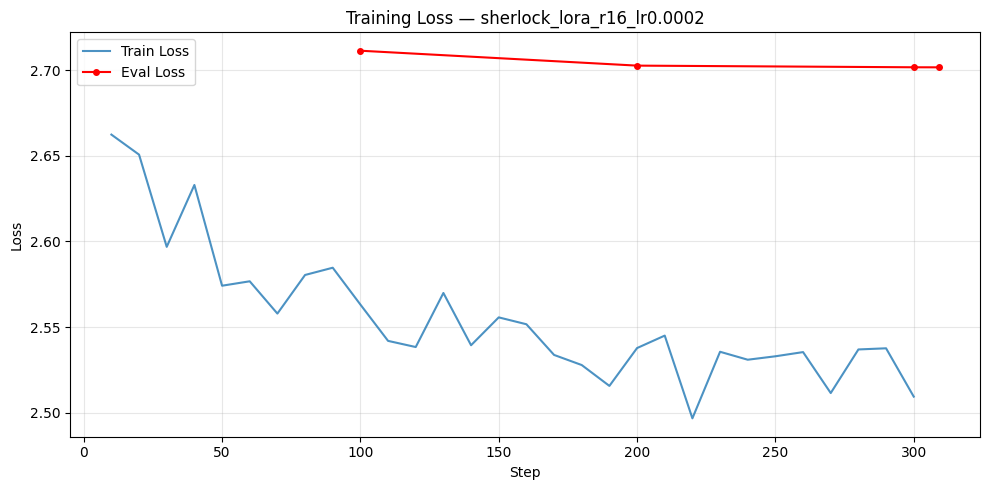

Saved: outputs\baseline/training_loss.png


In [15]:
# Plot training loss from trainer state
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# Extract training losses
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]

# Extract eval losses
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_steps, train_losses, label='Train Loss', alpha=0.8)
if eval_losses:
    ax.plot(eval_steps, eval_losses, 'ro-', label='Eval Loss', markersize=4)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title(f'Training Loss — {EXPERIMENT_NAME}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/training_loss.png')